# 1 — Exploratory Data Analysis (EDA)
Notebook ini membaca `data/raw/dataset.csv` lalu melakukan EDA dasar (ringkasan, missing values, distribusi, korelasi).

In [1]:
# Setup path + imports
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_theme()

ROOT = Path.cwd().resolve()
while not (ROOT / 'src').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

DATASET_PATH = ROOT / 'data' / 'raw' / 'dataset.csv'
DATASET_PATH

WindowsPath('C:/Users/bobok/modul2_datamining/data/raw/dataset.csv')

In [2]:
# Load dataset
if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Dataset tidak ditemukan: {DATASET_PATH}')

df = pd.read_csv(DATASET_PATH)
print('Shape:', df.shape)
df.head()

Shape: (54, 6)


,age,income,education,experience,credit_score,purchased
0,25,30000,High School,1,650,0
1,30,35000,Bachelor,3,680,0
2,35,40000,Bachelor,5,700,1
3,40,45000,Master,7,720,1
4,45,50000,Master,9,750,1


In [3]:
# Info umum
display(df.info())
df.describe(include='all')

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   age           54 non-null     int64
 1   income        54 non-null     int64
 2   education     54 non-null     str  
 3   experience    54 non-null     int64
 4   credit_score  54 non-null     int64
 5   purchased     54 non-null     int64
dtypes: int64(5), str(1)
memory usage: 2.7 KB


None

,age,income,education,experience,credit_score,purchased
count,54.000000,54.000000,54,54.000000,54.000000,54.000000
unique,NaN,NaN,4,NaN,NaN,NaN
top,NaN,NaN,Master,NaN,NaN,NaN
freq,NaN,NaN,20,NaN,NaN,NaN
mean,39.722222,44925.925926,NaN,6.759259,723.425926,0.759259
std,10.087198,10496.813266,NaN,4.027899,49.560179,0.431548
min,22.000000,27000.000000,NaN,0.000000,630.000000,0.000000
25%,31.250000,36500.000000,NaN,3.250000,686.250000,1.000000
50%,40.000000,44500.000000,NaN,7.000000,721.000000,1.000000
75%,48.000000,51750.000000,NaN,10.000000,759.500000,1.000000


In [4]:
# Missing values & duplicates
missing = df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])
print('Duplicate rows:', df.duplicated().sum())

Series([], dtype: int64)

Duplicate rows: 0


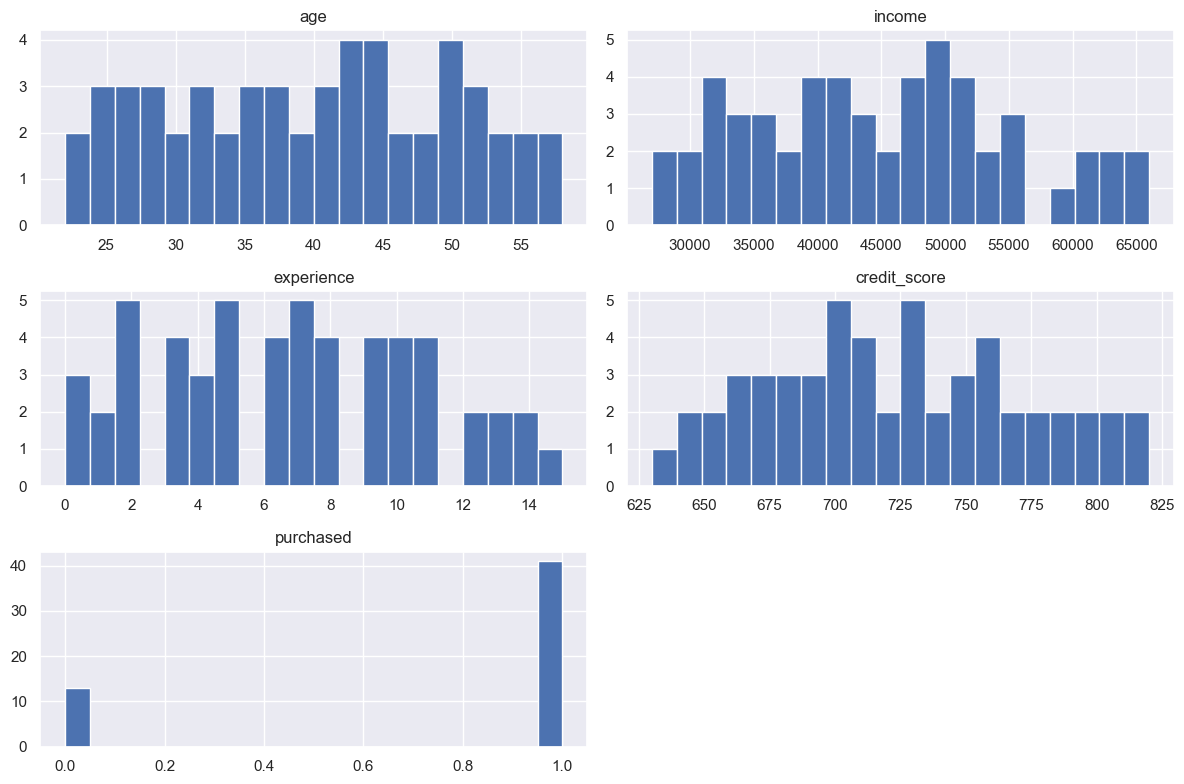

In [5]:
# Distribusi kolom numerik
num_cols = df.select_dtypes(include=['number']).columns.tolist()
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.tight_layout()
plt.show()

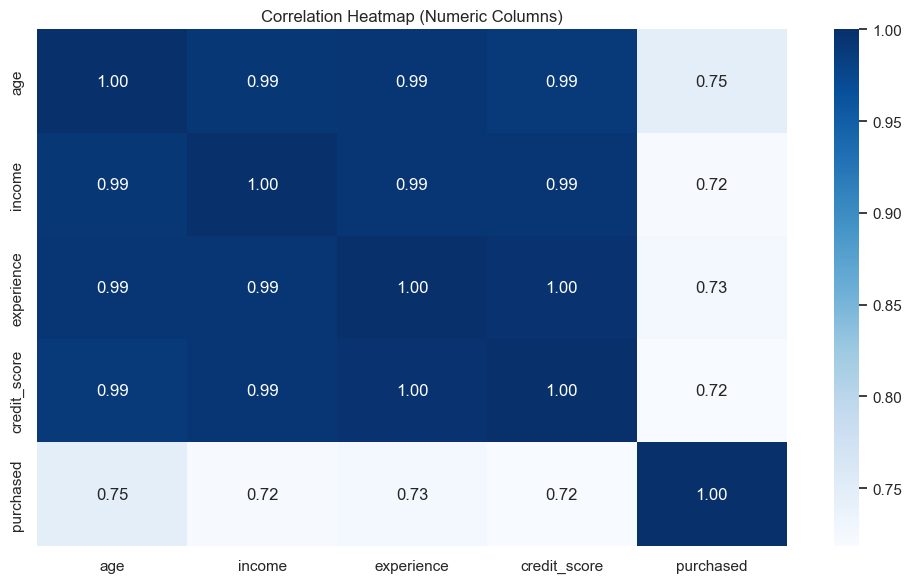

In [6]:
# Korelasi (numerik)
if len(num_cols) >= 2:
    corr = df[num_cols].corr(numeric_only=True)
    plt.figure(figsize=(10, 6))
    sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f')
    plt.title('Correlation Heatmap (Numeric Columns)')
    plt.tight_layout()
    plt.show()
else:
    print('Tidak cukup kolom numerik untuk korelasi.')